# Engineering Modelling 2 - Assignment 2
Yaman Ashqar - a1884774

### Q1(a)

The residual is:

$$
\mathbf{f}(\mathbf{u}) = \begin{bmatrix} -2u_1 + u_2 + \mu e^{u_1} \\ u_1 - 2u_2 + \mu e^{u_2} \end{bmatrix}
$$

The Jacobian is obtained by taking partial derivatives of each component of $\mathbf{f}$ with respect to $u_1$ and $u_2$:

$$
J(\mathbf{u}) = \begin{bmatrix} \dfrac{\partial f_1}{\partial u_1} & \dfrac{\partial f_1}{\partial u_2} \\[10pt] \dfrac{\partial f_2}{\partial u_1} & \dfrac{\partial f_2}{\partial u_2} \end{bmatrix} = \begin{bmatrix} -2 + \mu e^{u_1} & 1 \\ 1 & -2 + \mu e^{u_2} \end{bmatrix}
$$

### Q1(b)

Newton's method update: solve $J(\mathbf{u}_0)\,\boldsymbol{\delta} = -\mathbf{f}(\mathbf{u}_0)$, then $\mathbf{u}_1 = \mathbf{u}_0 + \boldsymbol{\delta}$.

**Evaluate $\mathbf{f}(\mathbf{u}_0)$ at $\mathbf{u}_0 = [0, -\ln 2]^\top$, $\mu = 2$:**

$$
f_1 = -2(0) + (-\ln 2) + 2e^{0} = 2 - \ln 2 \approx 1.3069
$$

$$
f_2 = 0 - 2(-\ln 2) + 2e^{-\ln 2} = 2\ln 2 + 1 \approx 2.3863
$$

$$
\mathbf{f}(\mathbf{u}_0) = \begin{bmatrix} 2 - \ln 2 \\ 1 + 2\ln 2 \end{bmatrix}
$$

**Evaluate $J(\mathbf{u}_0)$:**

$$
J_{11} = -2 + 2e^{0} = 0, \quad J_{12} = 1, \quad J_{21} = 1, \quad J_{22} = -2 + 2e^{-\ln 2} = -1
$$

$$
J(\mathbf{u}_0) = \begin{bmatrix} 0 & 1 \\ 1 & -1 \end{bmatrix}
$$

**Solve $J(\mathbf{u}_0)\,\boldsymbol{\delta} = -\mathbf{f}(\mathbf{u}_0)$:**

$$
\begin{bmatrix} 0 & 1 \\ 1 & -1 \end{bmatrix} \begin{bmatrix} \delta_1 \\ \delta_2 \end{bmatrix} = \begin{bmatrix} \ln 2 - 2 \\ -1 - 2\ln 2 \end{bmatrix}
$$

Row 1 gives $\delta_2 = \ln 2 - 2$. Substituting into row 2:

$$
\delta_1 = -1 - 2\ln 2 + (\ln 2 - 2) = -3 - \ln 2
$$

$$
\boldsymbol{\delta} = \begin{bmatrix} -3 - \ln 2 \\ \ln 2 - 2 \end{bmatrix} \approx \begin{bmatrix} -3.6931 \\ -1.3069 \end{bmatrix}
$$

**Final:**

$$
\mathbf{u}_1 = \mathbf{u}_0 + \boldsymbol{\delta} = \begin{bmatrix} 0 \\ -\ln 2 \end{bmatrix} + \begin{bmatrix} -3-\ln 2 \\ \ln 2 - 2 \end{bmatrix} = \begin{bmatrix} -3 - \ln 2 \\ -2 \end{bmatrix} \approx \begin{bmatrix} -3.6931 \\ -2.0000 \end{bmatrix}
$$

In [22]:
import numpy as np

# q1(b) verification
mu = 2
u0 = np.array([0, -np.log(2)])

f0 = np.array([
    -2*u0[0] + u0[1] + mu*np.exp(u0[0]),
    u0[0] - 2*u0[1] + mu*np.exp(u0[1])
])

J0 = np.array([
    [-2 + mu*np.exp(u0[0]), 1],
    [1, -2 + mu*np.exp(u0[1])]
])

delta = np.linalg.solve(J0, -f0)
u1 = u0 + delta

print(f"f(u0) = {f0}")
print(f"J(u0) = \n{J0}")
print(f"delta = {delta}")
print(f"u1    = {u1}")
print(f"u1 (exact) = [{-3 - np.log(2):.6f}, -2.000000]")

f(u0) = [1.30685282 2.38629436]
J(u0) = 
[[ 0.  1.]
 [ 1. -1.]]
delta = [-3.69314718 -1.30685282]
u1    = [-3.69314718 -2.        ]
u1 (exact) = [-3.693147, -2.000000]


### Q1(c)

In [23]:
import numpy as np

# q1(c): Newton's method for the nonlinear system with mu = 0.3

mu = 0.3

def f(u):
    return np.array([
        -2*u[0] + u[1] + mu*np.exp(u[0]),
        u[0] - 2*u[1] + mu*np.exp(u[1])
    ])

def J(u):
    return np.array([
        [-2 + mu*np.exp(u[0]), 1],
        [1, -2 + mu*np.exp(u[1])]
    ])

# newton's method
u = np.array([0.0, 0.0])
tol = 1e-10
max_iter = 50

print(f"{'Iter':>4}  {'u1':>12}  {'u2':>12}  {'||f(u)||':>12}")
print(f"{'0':>4}  {u[0]:>12.8f}  {u[1]:>12.8f}  {np.linalg.norm(f(u)):>12.6e}")

for i in range(1, max_iter + 1):
    fu = f(u)
    Ju = J(u)
    delta = np.linalg.solve(Ju, -fu)
    u = u + delta
    res = np.linalg.norm(f(u))
    print(f"{i:>4}  {u[0]:>12.8f}  {u[1]:>12.8f}  {res:>12.6e}")
    if res < tol:
        print(f"\nConverged in {i} iterations.")
        break

print(f"\nSolution: u1 = {u[0]:.10f}, u2 = {u[1]:.10f}")
print(f"Residual norm: {np.linalg.norm(f(u)):.6e}")

Iter            u1            u2      ||f(u)||
   0    0.00000000    0.00000000  4.242641e-01
   1    0.42857143    0.42857143  4.518055e-02
   2    0.48779032    0.48779032  1.164845e-03
   3    0.48940099    0.48940099  8.967946e-07
   4    0.48940223    0.48940223  5.338314e-13

Converged in 4 iterations.

Solution: u1 = 0.4894022272, u2 = 0.4894022272
Residual norm: 5.338314e-13


### Q1(c) code Output

| Iter | u1 | u2 | \|\|f(u)\|\| |
|------|------------|------------|--------------|
| 0 | 0.00000000 | 0.00000000 | 4.242641e-01 |
| 1 | 0.42857143 | 0.42857143 | 4.518055e-02 |
| 2 | 0.48779032 | 0.48779032 | 1.164845e-03 |
| 3 | 0.48940099 | 0.48940099 | 8.967946e-07 |
| 4 | 0.48940223 | 0.48940223 | 5.338314e-13 |

Converged in 4 iterations.

**Solution:** $u_1 = 0.4894022272$, $u_2 = 0.4894022272$

**Residual norm:** $5.338314 \times 10^{-13}$

The solution is symmetric ($u_1 = u_2$), which is consistent with the symmetry of the system (1). 
Newton's method exhibits quadratic convergence, with the residual roughly squaring each iteration 
(e.g. $10^{-3}, 10^{-7}, 10^{-13}$), converging in just 4 iterations.

### Q2(a)

For the model problem $y' = \lambda y$, substituting $f(t,y) = \lambda y$ and letting $z = \lambda h$:

$$F_1 = h\lambda y_k = z\, y_k$$

$$F_2 = h\lambda\!\left(y_k + \tfrac{1}{2}F_1\right) = z\!\left(1 + \tfrac{1}{2}z\right)y_k$$

$$F_3 = h\lambda\!\left(y_k + \tfrac{3}{4}F_2\right) = z\!\left(1 + \tfrac{3}{4}z + \tfrac{3}{8}z^2\right)y_k$$

Substituting into the update formula:

$$y_{k+1} = y_k + \frac{1}{9}\left[2z + 3z\!\left(1+\tfrac{1}{2}z\right) + 4z\!\left(1+\tfrac{3}{4}z+\tfrac{3}{8}z^2\right)\right]y_k$$

Expanding:

$$= y_k + \frac{1}{9}\left[9z + \frac{9}{2}z^2 + \frac{3}{2}z^3\right]y_k$$

$${y_{k+1} = \left(1 + \lambda h + \frac{1}{2}(\lambda h)^2 + \frac{1}{6}(\lambda h)^3\right)y_k}$$

### Q2(b)

Substituting $y_k = C\sigma^k$ into $y_{k+1} = p(\lambda h)\, y_k$:

$$C\sigma^{k+1} = p(\lambda h)\cdot C\sigma^k$$

Dividing both sides by $C\sigma^k$:

$${\sigma = 1 + \lambda h + \frac{1}{2}(\lambda h)^2 + \frac{1}{6}(\lambda h)^3}$$

### Q2(c)

Stability requires $|\sigma| \leq 1$. From Figure 1, $\sigma = -1$ at the lower boundary.
Finding this crossing point by solving $p(z) = -1$, i.e. $\tfrac{1}{6}z^3 + \tfrac{1}{2}z^2 + z + 2 = 0$:

In [24]:
import numpy as np

coeffs = [1/6, 1/2, 1, 2]
roots = np.roots(coeffs)
real_roots = roots[np.isreal(roots)].real
print(f"Stability boundary: λh = {real_roots[0]:.4f}")
print(f"Maximum step size:  h = {abs(real_roots[0]):.4f} / |λ|")

Stability boundary: λh = -2.5127
Maximum step size:  h = 2.5127 / |λ|


From the graph and numerical computation, $\sigma = -1$ at $\lambda h \approx -2.5127$, giving:

$$h_{\max} = \frac{2.5127}{|\lambda|}$$

For the forward Euler method, $\sigma = 1 + \lambda h$, which gives $|\sigma| \leq 1$ only for 
$\lambda h \in [-2, 0]$, so $h_{\max} = \dfrac{2}{|\lambda|}$.

The third-order Runge-Kutta method (2) has a stability limit approximately 25% larger than forward Euler, 
allowing a larger step size for the same $\lambda$.

### Q3(a)

Introduce the state vector $\mathbf{y} = [y_1, y_2, y_3, y_4]^\top$ where:

$$y_1 = x, \quad y_2 = x', \quad y_3 = y, \quad y_4 = y'$$

The system $\mathbf{y}' = \mathbf{f}(t, \mathbf{y};\mu)$ is then:

$$
\mathbf{f}(\mathbf{y};\mu) = \begin{bmatrix} y_2 \\[6pt] 2y_4 + y_1 - \dfrac{(1-\mu)(y_1+\mu)}{d^3} - \dfrac{\mu(y_1+\mu-1)}{r^3} \\[10pt] y_4 \\[6pt] -2y_2 + y_3 - \dfrac{(1-\mu)\,y_3}{d^3} - \dfrac{\mu\, y_3}{r^3} \end{bmatrix}
$$

where:

$$d = \sqrt{(y_1+\mu)^2 + y_3^2}, \qquad r = \sqrt{(y_1+\mu-1)^2 + y_3^2}$$

Note that $t$ does not appear explicitly in $\mathbf{f}$, so the system is autonomous.

### Q3(b)

Success: True
Message: The solver successfully reached the end of the integration interval.


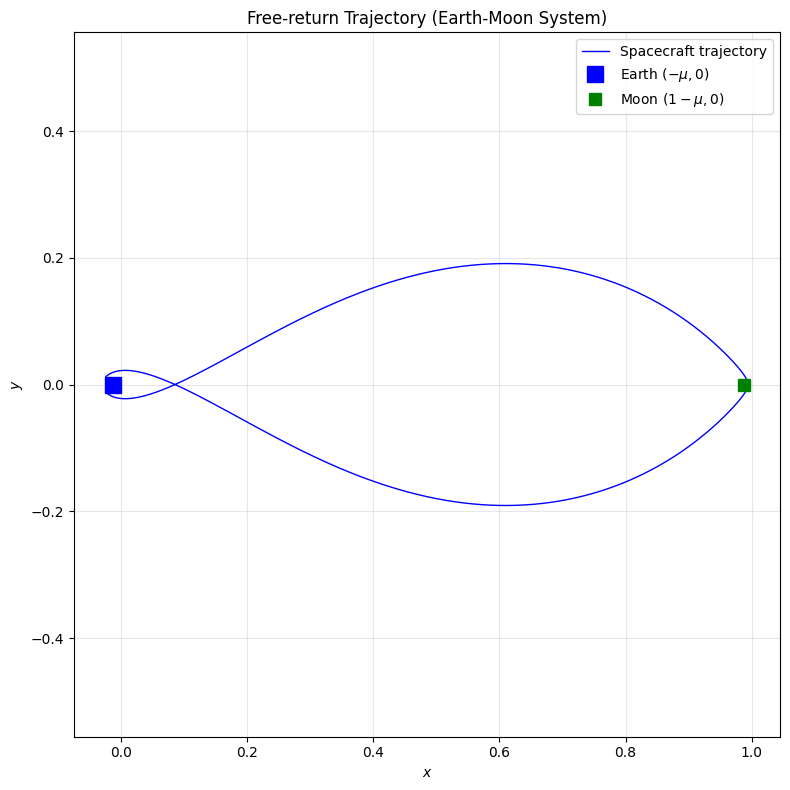

In [25]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

mu = 1.21506e-2

def f(t, y):
    y1, y2, y3, y4 = y  # x, x', y, y'
    
    d = np.sqrt((y1 + mu)**2 + y3**2)
    r = np.sqrt((y1 + mu - 1)**2 + y3**2)
    
    dy1 = y2
    dy2 = 2*y4 + y1 - (1-mu)*(y1+mu)/d**3 - mu*(y1+mu-1)/r**3
    dy3 = y4
    dy4 = -2*y2 + y3 - (1-mu)*y3/d**3 - mu*y3/r**3
    
    return [dy1, dy2, dy3, dy4]

# initial conditions: [x(0), x'(0), y(0), y'(0)]
y0 = [-0.0233267, 8.03118, -0.0125213, -7.16836]
t_span = (0, 1.36569)
t_eval = np.linspace(0, 1.36569, 10000)

sol = solve_ivp(f, t_span, y0, method='RK45', t_eval=t_eval,
                rtol=1e-10, atol=1e-12)

print(f"Success: {sol.success}")
print(f"Message: {sol.message}")

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(sol.y[0], sol.y[2], 'b-', linewidth=1, label='Spacecraft trajectory')
ax.plot(-mu, 0, 'bs', markersize=12, label=f'Earth $(-\\mu, 0)$')
ax.plot(1-mu, 0, 'gs', markersize=8,  label=f'Moon $(1-\\mu, 0)$')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Free-return Trajectory (Earth-Moon System)')
ax.axis('equal')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('free_return_trajectory.png', dpi=150)
plt.show()

### Q4(a)

Design variables: $A_1$ (cm²), $A_2$ (cm²), $y$ (m), with $b = 3$ m, $P = 50$ kN, $E = 200$ GPa, $\sigma_{\max} = 125$ MPa.

Objective function (minimise semivolume):

$$\min_{A_1,\, A_2,\, y} \quad f(A_1, A_2, y) = A_1\sqrt{9 + y^2} + 3A_2$$

Constraints:

1. Stress in top members must not exceed $\sigma_{\max}$:
$$g_1: \quad \frac{250\sqrt{9+y^2}}{A_1\, y} \leq 125$$

2. Stress in bottom member must not exceed $\sigma_{\max}$:
$$g_2: \quad \frac{750}{A_2\, y} \leq 125$$

3. Buckling constraint on top members ($F_1 \leq F_{cr}$, with $I = A_1^2/12$):
$$g_3: \quad \frac{25\sqrt{9+y^2}}{y} \leq \frac{\pi^2 (200)\, A_1^2}{1200(9+y^2)}$$

4. Bounds on design variables:
$$A_1 > 0, \quad A_2 > 0, \quad y \geq 0$$

### Q4(b)

In [26]:
import numpy as np
from scipy.optimize import minimize

# Q4(b): Constrained optimisation of truss

b = 3       # m
P = 50      # kN
E = 200     # GPa
sigma_max = 125  # MPa

def objective(x):
    A1, A2, y = x
    return A1 * np.sqrt(b**2 + y**2) + b * A2

# constraints as g(x) >= 0 for scipy
def g1(x):
    # sigma1 <= sigma_max  ->  sigma_max - sigma1 >= 0
    A1, A2, y = x
    return sigma_max - (5*P / A1) * (np.sqrt(b**2 + y**2) / y)

def g2(x):
    # sigma2 <= sigma_max  ->  sigma_max - sigma2 >= 0
    A1, A2, y = x
    return sigma_max - (5*P / A2) * (b / y)

def g3(x):
    # F1 <= F_cr  ->  F_cr - F1 >= 0
    A1, A2, y = x
    I = A1**2 / 12
    F1  = (P/2) * np.sqrt(b**2 + y**2) / y
    Fcr = (1/100) * (np.pi**2 * E * I) / (b**2 + y**2)
    return Fcr - F1

constraints = [
    {'type': 'ineq', 'fun': g1},
    {'type': 'ineq', 'fun': g2},
    {'type': 'ineq', 'fun': g3},
]

# bounds: A1 > 0, A2 > 0, y > 0
bounds = [(1e-6, None), (1e-6, None), (1e-6, None)]

# initial guess
x0 = [5.0, 5.0, 1.0]

result = minimize(objective, x0, method='SLSQP',
                  bounds=bounds, constraints=constraints,
                  options={'ftol': 1e-10, 'disp': True})

A1_opt, A2_opt, y_opt = result.x
print(f"\nOptimisation successful: {result.success}")
print(f"Message: {result.message}")
print(f"\nOptimal values:")
print(f"  A1 = {A1_opt:.6f} cm²")
print(f"  A2 = {A2_opt:.6f} cm²")
print(f"  y  = {y_opt:.6f} m")
print(f"\nMinimum semivolume = {result.fun:.6f} cm²·m")

# verify constraints at optimum
print(f"\nConstraint check at optimum:")
print(f"  g1 (stress top)    = {g1(result.x):.6f}  (>= 0)")
print(f"  g2 (stress bottom) = {g2(result.x):.6f}  (>= 0)")
print(f"  g3 (buckling)      = {g3(result.x):.6f}  (>= 0)")

Optimization terminated successfully    (Exit mode 0)
            Current function value: 76.52140952491463
            Iterations: 30
            Function evaluations: 125
            Gradient evaluations: 29

Optimisation successful: True
Message: Optimization terminated successfully

Optimal values:
  A1 = 19.035124 cm²
  A2 = 3.366865 cm²
  y  = 1.782073 m

Minimum semivolume = 76.521410 cm²·m

Constraint check at optimum:
  g1 (stress top)    = 99.283772  (>= 0)
  g2 (stress bottom) = -0.000000  (>= 0)
  g3 (buckling)      = -0.000000  (>= 0)


Output:
```
The optimiser converged successfully. At the optimum, the bottom member stress constraint ($g_2$) 
and the buckling constraint ($g_3$) are both active (binding), while the top member stress 
constraint ($g_1$) has significant slack. This means the optimal design is simultaneously 
limited by bottom member yielding and top member buckling.```